# Machine learning based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence

## Background and Context
### Real estate companies operate in markets where buyer behavior is highly diverse:

- Individual home buyers
- Institutional investors
- International buyers
- High-net-worth investors
= First-time buyers

## Problem Statement
### Parcl currently lacks a data-driven understanding of:

- Different types of property buyers
- Investment motivations across demographics
- Geographic differences in investment behavior
- Customer financing patterns  

### This leads to:

- Inefficient marketing spend
- Generic property recommendations
- Poor investor targeting

### Dataset Fields Description

| Feature              | Description                          |
|---------------------|--------------------------------------|
| client_id           | Unique client identifier             |
| client_type         | Individual / Corporate               |
| gender              | Gender of buyer                      |
| country             | Country of residence                 |
| region              | Geographic region                    |
| date_of_birth       | Age indicator                        |
| acquisition_purpose | Investment / Personal use            |
| loan_applied        | Financing indicator                  |
| referral_channel    | Source of customer acquisition       |
| satisfaction_score  | Customer satisfaction rating         |

## Load Libraries

In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Load Data

In [307]:
dfc = pd.read_csv('/content/clients.csv')
dfp = pd.read_csv('/content/properties.csv')

In [308]:
dfc.head(5)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [309]:
dfp.head(5)

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [310]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [311]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB


In [312]:
dfc.describe()

,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [313]:
dfp.describe()

,listing_id,tower_number,unit_number,floor_area_sqft
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,105898.277400,10.370100,28.99920,1139.941412
std,74414.566199,5.769025,16.88242,418.373967
min,1002.000000,1.000000,1.00000,410.710000
25%,50389.750000,5.000000,15.00000,782.200000
50%,100404.500000,10.000000,29.00000,1110.880000
75%,150411.250000,15.000000,43.00000,1499.000000
max,990026.000000,20.000000,70.00000,1957.160000


## Data Cleaning

### Handle Missing attributes

In [314]:
print("total number of clients : ",len(dfc))
print("total number of duplicates rows : ",dfc.duplicated('client_id').sum())
print("null values in each column:\n",dfc.isnull().sum())

total number of clients :  2000
total number of duplicates rows :  0
null values in each column:
 client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64


<font color="red"><b>Convert Data type of date_of_birth from object to datetime</d><font>

In [315]:
dfc['date_of_birth'] = dfc['date_of_birth'].str.replace('/','-')
dfc['date_of_birth'] = pd.to_datetime(dfc['date_of_birth'],format="%m-%d-%Y")

In [316]:
dfc.head(4)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website


<font color="red"><b>creating new column age</d><font>

In [317]:
cy = datetime.now().year
dfc['age'] = cy - dfc['date_of_birth'].dt.year

In [318]:
dfc['age'].describe()

,age
count,2000.000000
mean,56.099000
std,17.343719
min,26.000000
25%,41.000000
50%,57.000000
75%,71.000000
max,95.000000


In [319]:
dfc['age'].isnull().sum()

np.int64(0)

<font color="red"><b>Dropping Original Column dateofbirth</d><font>

In [320]:
dfc.drop(columns=['date_of_birth'],inplace=True)

<font color="red"><b>check null values in properties dataset and find any duplicates are there</d><font>

In [321]:
print("null values in the properties : ",dfp.isnull().sum())
print("duplicate values in the properties : ",dfp.duplicated().sum())
print("any duplicated in listingid : ",dfp['listing_id'].duplicated().sum())

null values in the properties :  listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64
duplicate values in the properties :  0
any duplicated in listingid :  0


In [322]:
print("Client Ref Missing Date Percentage : ",(dfp['client_ref'].isnull().sum()/len(dfp)) * 100)

Client Ref Missing Date Percentage :  26.950000000000003


<font color="red"><b>Remving null values</d><font>

In [323]:
dfp = dfp.dropna(subset=['client_ref'])

<font color="red"><b>Handling Sales Price</d><font>

In [324]:
# dfp.loc[:, 'sale_price'] = dfp['sale_price'].str.replace(r'[$,]', '', regex=True).astype('float64')

dfp['sale_price'] = pd.to_numeric(dfp['sale_price'].astype(str).str.replace(r'[$,]', '', regex=True))


<font color="red"><b>Handling transaction date</d><font>

In [325]:
dfp['transaction_date'] = pd.to_datetime(dfp['transaction_date'],format="%m-%d-%Y")

In [326]:
dfp.head(4)

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,2024-01-01,Apartment,12,1160.36,300385.62,Sold,C0027
1,1015,1,2024-01-01,Apartment,15,782.25,208930.81,Sold,C0097
2,1021,1,2024-01-01,Apartment,21,756.21,218585.92,Sold,C0113
3,1030,1,2024-01-01,Apartment,30,743.09,246172.68,Sold,C0141


### Normalize categorical labels

In [327]:
dfc.head(3)

,client_id,client_type,first_name,last_name,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age
0,C0001,Individual,Kareem,Liu,F,USA,California,Home,4,Yes,Website,58
1,C0002,Individual,Trystan,Oconnor,M,USA,California,Home,1,No,Website,64
2,C0003,Individual,Kale,Gay,M,USA,California,Home,4,Yes,Agency,67


In [328]:
dfc_cat = dfc.select_dtypes(include=['object']).columns.to_list()

In [329]:
for i in dfc_cat:
  print("="*30)
  print(dfc[i].value_counts())

client_id
C1984    1
C1983    1
C1982    1
C1981    1
C1980    1
        ..
C0005    1
C0004    1
C0003    1
C0002    1
C0001    1
Name: count, Length: 2000, dtype: int64
client_type
Individual    1897
Company        103
Name: count, dtype: int64
first_name
Carl       24
Gerald     20
Jason      19
William    19
Sarah      19
           ..
Apex        1
Skylar      1
Kareem      1
Polaris     1
Trystan     1
Name: count, Length: 337, dtype: int64
last_name
Co         103
Howard      39
Morales     34
Hansen      34
Cox         33
          ... 
Pugh         1
Crane        1
Irwin        1
Stout        1
Simmons      1
Name: count, Length: 224, dtype: int64
gender
M    1012
F     988
Name: count, dtype: int64
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64
region
California                633
Nevada                    143
C

<font color="red"><b>Convert Categorical column in lower case</d><font>

In [330]:
for i in dfc_cat:
  dfc[i] = dfc[i].str.lower()

<font color="red"><b>Handling Gender</d><font>

In [331]:
dfc['gender'] = dfc['gender'].map({"m":"male","f":"female"})

<font color="red"><b>Properties categorical column</d><font>

In [332]:
dfp_cat = dfp.select_dtypes(include=['object']).columns.to_list()
dfp_cat

['unit_category', 'listing_status', 'client_ref']

In [333]:
for i in dfp_cat:
  dfp[i] = dfp[i].str.lower()

<font color="red"><b>Aggregate properties per client</b></font>

In [334]:
dfp_agg = dfp.groupby('client_ref').agg({
    'listing_id': 'count',
    'sale_price': ['sum', 'mean'],
    'floor_area_sqft': 'mean'
}).reset_index()

In [335]:
dfp_agg.columns = [
    'client_id',
    'property_count',
    'total_investment',
    'avg_investment',
    'avg_area'
]

<font color="red"><b>Merge wiht client data</b></font>

In [336]:
# final_df = dfc.merge(dfp_agg, on='client_id', how='inner')
final_df = dfc.merge(dfp_agg, on='client_id', how='left')
final_df[['property_count','total_investment','avg_investment','avg_area']] = \
    final_df[['property_count','total_investment','avg_investment','avg_area']].fillna(0)

In [337]:
final_df.head(4)

,client_id,client_type,first_name,last_name,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,property_count,total_investment,avg_investment,avg_area
0,c0001,individual,kareem,liu,female,usa,california,home,4,yes,website,58,4,1246764.72,311691.180000,983.885000
1,c0002,individual,trystan,oconnor,male,usa,california,home,1,no,website,64,5,1841095.93,368219.186000,1187.942000
2,c0003,individual,kale,gay,male,usa,california,home,4,yes,agency,67,5,1661457.59,332291.518000,1058.110000
3,c0004,individual,russell,gross,male,usa,california,home,5,no,website,67,6,1608263.51,268043.918333,937.103333


## Feature Encoding and Feature Scaling and Cluster Model selection

<font color="red"><b>Reduce high-cardinality columns</b></font>

In [338]:
top_regions = final_df['region'].value_counts().nlargest(10).index

final_df['region'] = final_df['region'].apply(
    lambda x: x if x in top_regions else 'other'
)

In [339]:
top_countries = final_df['country'].value_counts().nlargest(5).index

final_df['country'] = final_df['country'].apply(
    lambda x: x if x in top_countries else 'other'
)

In [340]:
categorical_columns = ['client_type','country','region','acquisition_purpose','referral_channel','gender','loan_applied']

numerical_columns = ['age','satisfaction_score','property_count','total_investment','avg_investment','avg_area']

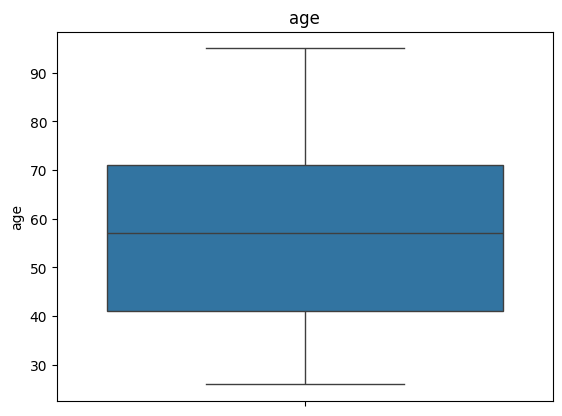

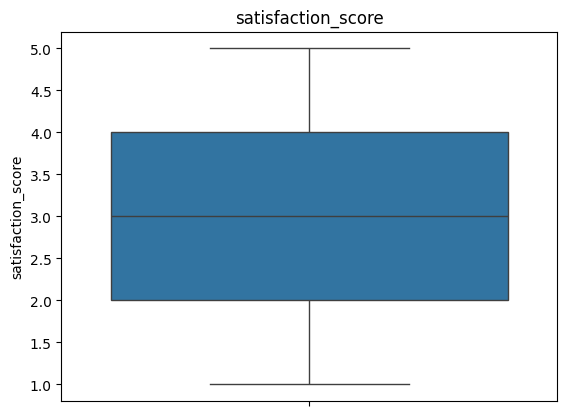

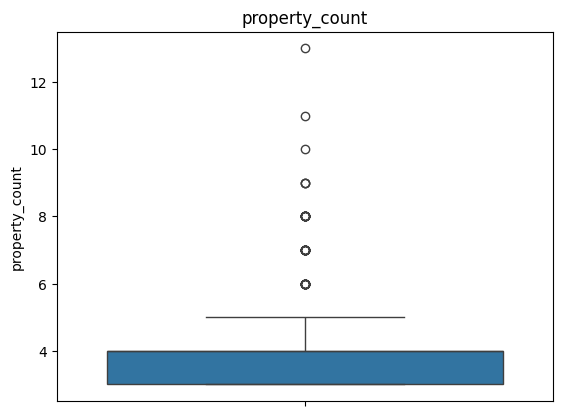

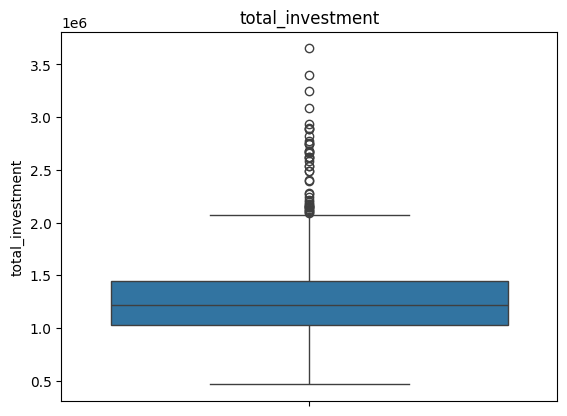

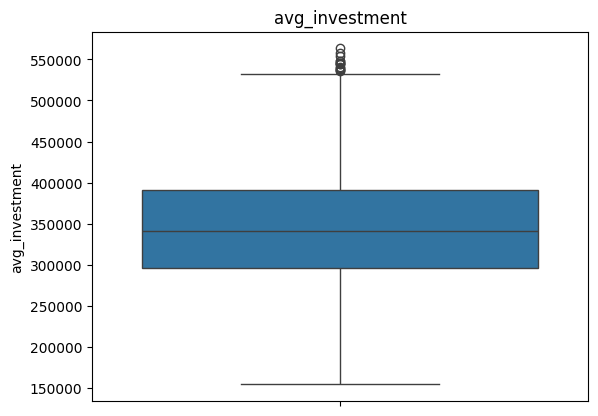

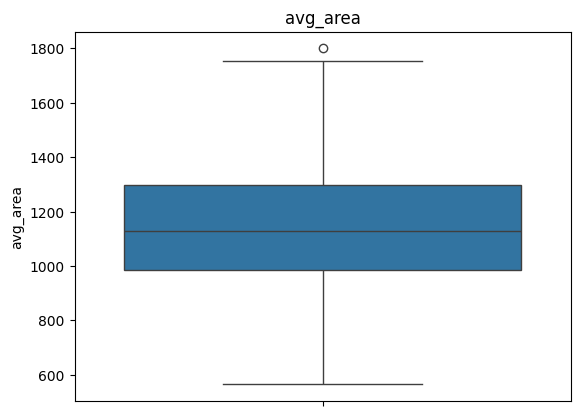

In [341]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_columns:
    plt.figure()
    sns.boxplot(y=final_df[col])
    plt.title(col)
    plt.show()

<font color="red"><b>Apply capping</b></font>

In [342]:
for col in ['property_count', 'total_investment', 'avg_investment', 'avg_area']:
    upper = final_df[col].quantile(0.99)
    lower = final_df[col].quantile(0.01)

    final_df[col] = final_df[col].clip(lower, upper)

In [343]:
for col in numerical_columns:
  print(col,":  ",final_df[col].skew())

age :   -0.0012791228073594783
satisfaction_score :   -0.040697024486541965
property_count :   1.8253430442444112
total_investment :   1.013461922431812
avg_investment :   0.38614205313098626
avg_area :   0.3090983434437303


In [344]:
categorical_columns = ['client_type','country','region','acquisition_purpose','referral_channel','gender','loan_applied']
numerical_columns = ['age','satisfaction_score','property_count','total_investment','avg_investment','avg_area']

In [345]:

#rescale satisfaction score
final_df['satisfaction_score'] = final_df['satisfaction_score'] * 2

# drop weak categoricals
final_df.drop(columns=['first_name','last_name','referral_channel','gender'], inplace=True)

# Updated column lists
categorical_columns = ['client_type','country','region',
                       'acquisition_purpose','loan_applied']

numerical_columns = ['age','satisfaction_score','property_count',
                     'total_investment','avg_investment','avg_area']

print(f"Shape after fixes: {final_df.shape}")
print(f"Satisfaction score range: {final_df['satisfaction_score'].min()} - {final_df['satisfaction_score'].max()}")
print(f"Clients with 0 properties: {(final_df['property_count']==0).sum()}")

Shape after fixes: (2000, 12)
Satisfaction score range: 2 - 10
Clients with 0 properties: 0


<font color="red"><b>Apply hot encoding and Scaling</b></font>

In [346]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_columns),
    ('num', StandardScaler(), numerical_columns)
])

### Pipeline

<font color="red"><b>K means</b></font>

In [347]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])

In [348]:
pipeline.fit(final_df.drop(columns=['client_id']))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['client_type', 'country',
                                                   'region',
                                                   'acquisition_purpose',
                                                   'loan_applied']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'satisfaction_score',
                                                   'property_count',
                                                   'total_investment',
                                                   'avg_investment',
                                                   'avg_area'])])),
                ('kmeans', KMeans(n_clusters=4, random_state=42))])

In [349]:
final_df['cluster'] = pipeline.predict(final_df.drop(columns=['client_id']))

## Optimal Cluster Selection

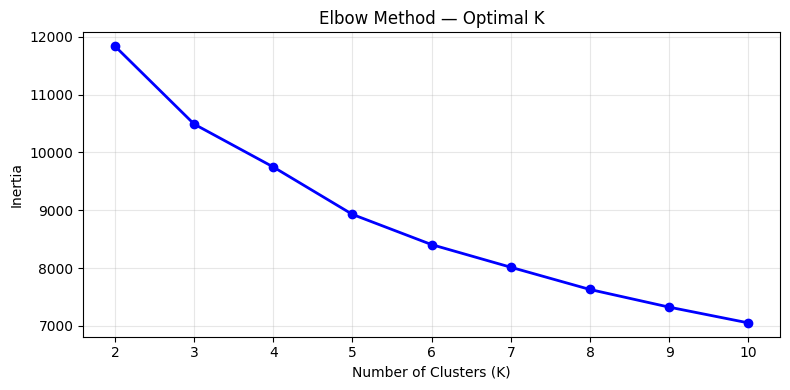

Look for the BEND/ELBOW point in the curve — that's your best K


In [350]:
import os
from sklearn.cluster import KMeans

X = preprocessor.fit_transform(final_df.drop(columns=['client_id']))

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)



plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Look for the BEND/ELBOW point in the curve — that's your best K")

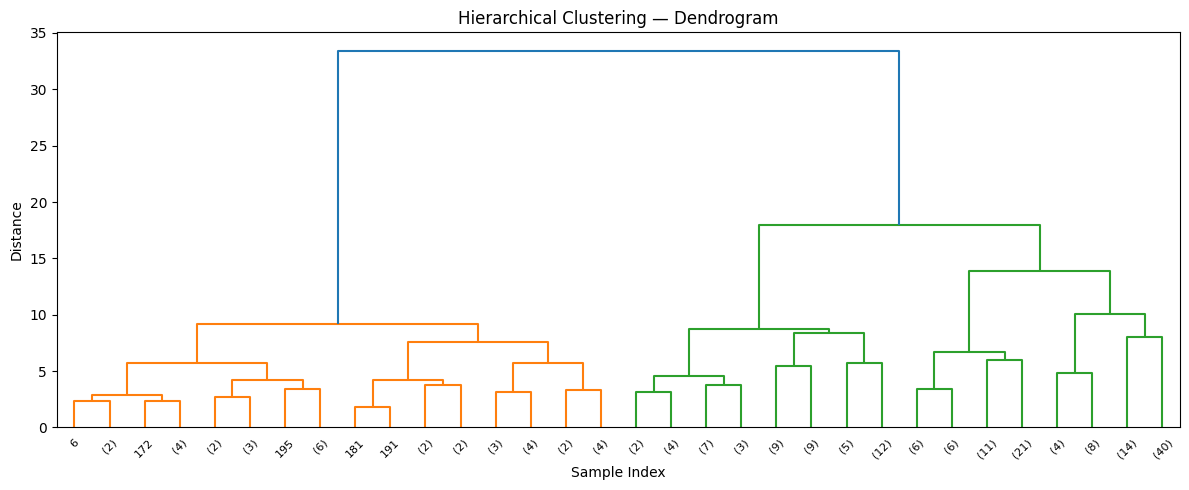

Look for the LARGEST vertical gap — that's the suggested number of clusters


In [351]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a sample of 200 rows for dendrogram (full 2000 is unreadable)
X_sample = X[:200]

# Plot Dendrogram
linked = linkage(X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample,
                 method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=4,
           leaf_rotation=45, leaf_font_size=8)
plt.title('Hierarchical Clustering — Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()
print("Look for the LARGEST vertical gap — that's the suggested number of clusters")

In [352]:
# Replace 4 with whatever K the elbow plot suggests
BEST_K = 4

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=BEST_K, random_state=42, n_init=10))
])

pipeline.fit(final_df.drop(columns=['client_id']))
final_df['cluster'] = pipeline.predict(final_df.drop(columns=['client_id']))

print(f"Cluster distribution:\n{final_df['cluster'].value_counts().sort_index()}")

Cluster distribution:
cluster
0    406
1    535
2    569
3    490
Name: count, dtype: int64


<font color="red"><b>silhouette_score</b></font>

In [353]:
from sklearn.metrics import silhouette_score

# Use the already transformed X from Step 4
X = preprocessor.transform(final_df.drop(columns=['client_id']))

labels = final_df['cluster']

score = silhouette_score(X, labels)
print(f"Silhouette Score for K=4: {score:.4f}")

Silhouette Score for K=4: 0.1361


In [354]:
from sklearn.metrics import silhouette_score

X = preprocessor.transform(final_df.drop(columns=['client_id']))

# Compare silhouette across different K values
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k}  →  Silhouette Score: {score:.4f}")

K=3  →  Silhouette Score: 0.2067
K=4  →  Silhouette Score: 0.1361
K=5  →  Silhouette Score: 0.1292
K=6  →  Silhouette Score: 0.1259
K=7  →  Silhouette Score: 0.1261


##  Cluster Interpretation

<font color="red"><b>cluster distribution</b></font>

In [355]:
cluster_sizes = final_df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_sizes.items():
    pct = (count / len(final_df)) * 100
    print(f"Cluster {cluster_id}: {count:4d} buyers ({pct:5.1f}%)")

Cluster 0:  406 buyers ( 20.3%)
Cluster 1:  535 buyers ( 26.8%)
Cluster 2:  569 buyers ( 28.4%)
Cluster 3:  490 buyers ( 24.5%)


<font color="red"><b>Investment Purpose</b></font>

In [356]:
purpose_pct = pd.crosstab(final_df['cluster'], final_df['acquisition_purpose'], normalize='index') * 100
print(purpose_pct.round(2))

acquisition_purpose   home  investment
cluster                               
0                    72.41       27.59
1                    67.29       32.71
2                    69.07       30.93
3                    68.98       31.02


<font color="red"><b>Loan behaviour</b></font>

In [357]:
loan_pct = pd.crosstab(final_df['cluster'], final_df['loan_applied'], normalize='index') * 100
print(loan_pct.round(2))

loan_applied     no    yes
cluster                   
0             64.29  35.71
1             63.93  36.07
2             63.09  36.91
3             61.63  38.37


<font color="red"><b>Geographic distribution</b></font>

In [358]:
for cluster_id in sorted(final_df['cluster'].unique()):
    cluster_data = final_df[final_df['cluster'] == cluster_id]
    top_region = cluster_data['region'].value_counts().index[0]
    print(f"Cluster {cluster_id}: {top_region}")

Cluster 0: california
Cluster 1: california
Cluster 2: other
Cluster 3: california


<font color="red"><b>DEMOGRAPHICS BY CLUSTER</b></font>

In [359]:
demographics = final_df.groupby('cluster').agg({
    'age': 'mean',
    'satisfaction_score': 'mean'
}).round(2)
print(demographics)

           age  satisfaction_score
cluster                           
0        62.04                7.27
1        53.93                3.08
2        56.35                8.22
3        53.26                5.80


In [360]:
financial = final_df.groupby('cluster')[['property_count', 'avg_investment','property_count']].mean()
financial

,property_count,avg_investment,property_count
cluster,,,
0,4.475369,359640.603988,4.475369
1,3.530841,309011.155124,3.530841
2,3.427065,296507.640039,3.427065
3,3.302041,437075.181329,3.302041


In [361]:
# ── CLUSTER TO BUYER SEGMENT MAPPING ──────────────────────────

segment_mapping = {
    0: 'C4 - Luxury Investors',
    1: 'C2 - First-Time Buyers',
    2: 'C1 - Global Investors',
    3: 'C3 - Corporate Buyers'
}

final_df['buyer_segment'] = final_df['cluster'].map(segment_mapping)

# ── VERIFY MAPPING ────────────────────────────────────────────

print("=" * 80)
print("FINAL BUYER SEGMENT MAPPING")
print("=" * 80)

for cluster_id, segment_name in segment_mapping.items():
    segment_data = final_df[final_df['cluster'] == cluster_id]
    print(f"\n{segment_name}")
    print(f"  Size: {len(segment_data)} buyers ({len(segment_data)/len(final_df)*100:.1f}%)")
    print(f"  Avg Age: {segment_data['age'].mean():.1f} years")
    print(f"  Avg Satisfaction: {segment_data['satisfaction_score'].mean():.2f}/10")
    print(f"  Investment %: {(segment_data['acquisition_purpose'].str.lower() == 'investment').sum()/len(segment_data)*100:.1f}%")
    print(f"  Loan %: {(segment_data['loan_applied'].str.lower() == 'yes').sum()/len(segment_data)*100:.1f}%")
    print(f"  Avg Properties: {segment_data['property_count'].mean():.2f}")
    print(f"  Avg Total Investment: ${segment_data['total_investment'].mean():,.0f}")
    print(f"  Avg Unit Price: ${segment_data['avg_investment'].mean():,.0f}")

print("\n" + "=" * 80)

print("=" * 80)

# Save final dataframe with segments
final_df.to_csv('final_df_with_segments.csv', index=False)
print("\n Saved: final_df_with_segments.csv")

FINAL BUYER SEGMENT MAPPING

C4 - Luxury Investors
  Size: 406 buyers (20.3%)
  Avg Age: 62.0 years
  Avg Satisfaction: 7.27/10
  Investment %: 27.6%
  Loan %: 35.7%
  Avg Properties: 4.48
  Avg Total Investment: $1,605,973
  Avg Unit Price: $359,641

C2 - First-Time Buyers
  Size: 535 buyers (26.8%)
  Avg Age: 53.9 years
  Avg Satisfaction: 3.08/10
  Investment %: 32.7%
  Loan %: 36.1%
  Avg Properties: 3.53
  Avg Total Investment: $1,087,492
  Avg Unit Price: $309,011

C1 - Global Investors
  Size: 569 buyers (28.4%)
  Avg Age: 56.3 years
  Avg Satisfaction: 8.22/10
  Investment %: 30.9%
  Loan %: 36.9%
  Avg Properties: 3.43
  Avg Total Investment: $1,009,837
  Avg Unit Price: $296,508

C3 - Corporate Buyers
  Size: 490 buyers (24.5%)
  Avg Age: 53.3 years
  Avg Satisfaction: 5.80/10
  Investment %: 31.0%
  Loan %: 38.4%
  Avg Properties: 3.30
  Avg Total Investment: $1,445,170
  Avg Unit Price: $437,075


 Saved: final_df_with_segments.csv


### Visualization

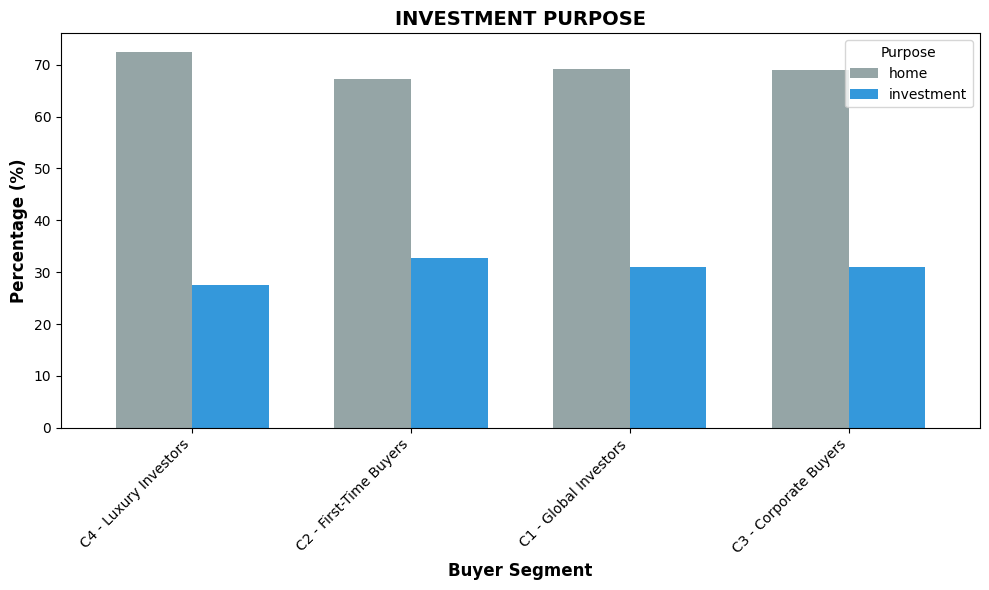

In [362]:
purpose_pct = pd.crosstab(final_df['cluster'], final_df['acquisition_purpose'], normalize='index') * 100
purpose_pct.plot(kind='bar', figsize=(10, 6), color=['#95a5a6', '#3498db'], width=0.7)

plt.title('INVESTMENT PURPOSE', fontsize=14, fontweight='bold')
plt.xlabel('Buyer Segment', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.xticks([0, 1, 2, 3], [segment_mapping[i] for i in range(4)], rotation=45, ha='right')
plt.legend(title='Purpose')
plt.tight_layout()
plt.show()

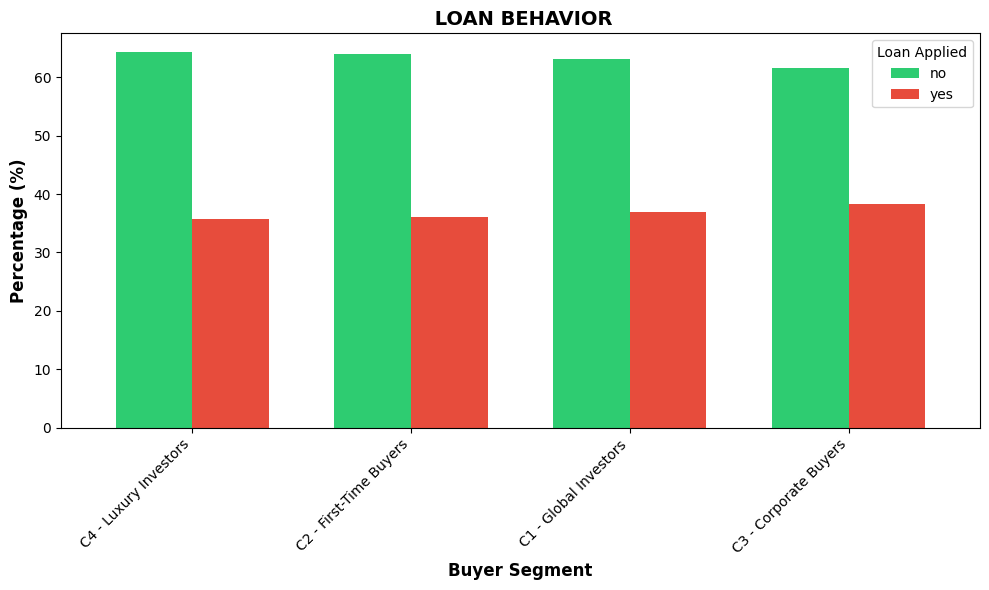

In [363]:
loan_pct = pd.crosstab(final_df['cluster'], final_df['loan_applied'], normalize='index') * 100
loan_pct.plot(kind='bar', figsize=(10, 6), color=['#2ecc71', '#e74c3c'], width=0.7)

plt.title(' LOAN BEHAVIOR', fontsize=14, fontweight='bold')
plt.xlabel('Buyer Segment', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.xticks([0, 1, 2, 3], [segment_mapping[i] for i in range(4)], rotation=45, ha='right')
plt.legend(title='Loan Applied')
plt.tight_layout()
plt.show()

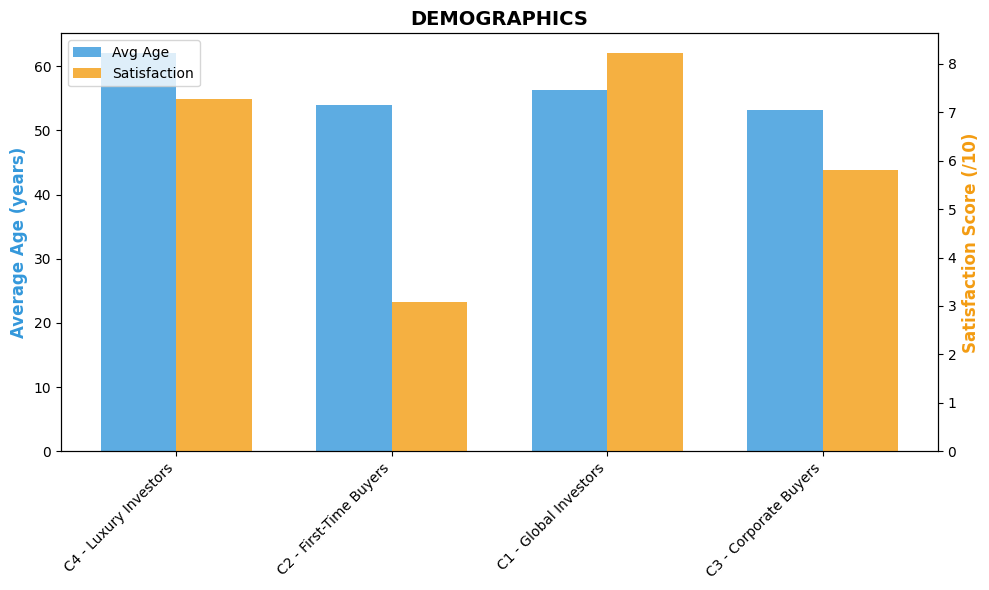

In [364]:


demographics = final_df.groupby('cluster')[['age', 'satisfaction_score']].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(demographics))
width = 0.35

bars1 = ax1.bar(x - width/2, demographics['age'], width, label='Avg Age', color='#3498db', alpha=0.8)
ax1.set_ylabel('Average Age (years)', fontsize=12, fontweight='bold', color='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels([segment_mapping[i] for i in range(4)], rotation=45, ha='right')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, demographics['satisfaction_score'], width, label='Satisfaction', color='#f39c12', alpha=0.8)
ax2.set_ylabel('Satisfaction Score (/10)', fontsize=12, fontweight='bold', color='#f39c12')

plt.title('DEMOGRAPHICS', fontsize=14, fontweight='bold')
ax1.legend([bars1, bars2], ['Avg Age', 'Satisfaction'], loc='upper left')
fig.tight_layout()
plt.show()

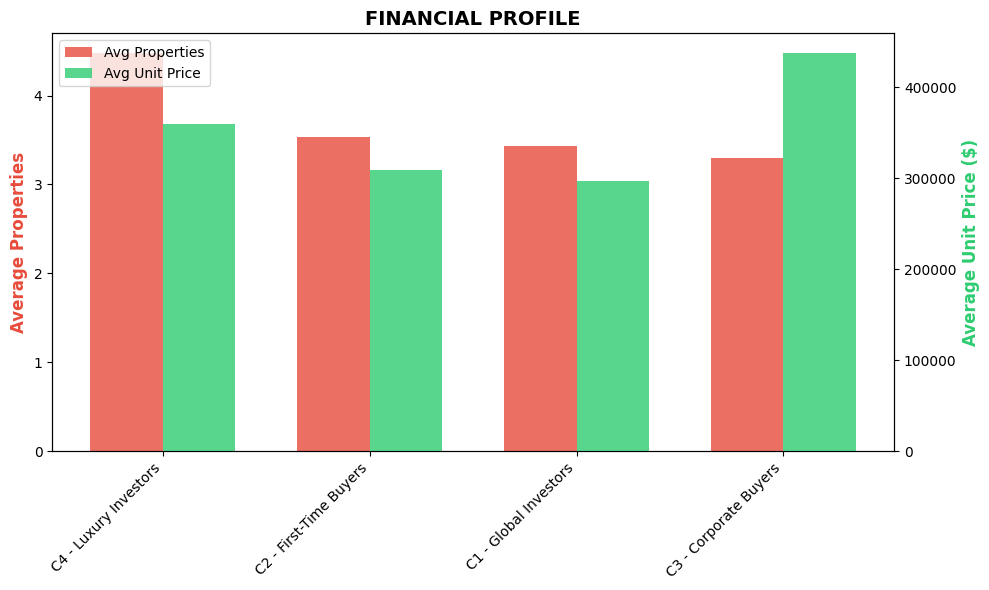

In [365]:
financial = final_df.groupby('cluster')[['property_count', 'avg_investment']].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(financial))
width = 0.35

bars1 = ax1.bar(x - width/2, financial['property_count'], width, label='Avg Properties', color='#e74c3c', alpha=0.8)
ax1.set_ylabel('Average Properties', fontsize=12, fontweight='bold', color='#e74c3c')
ax1.set_xticks(x)
ax1.set_xticklabels([segment_mapping[i] for i in range(4)], rotation=45, ha='right')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, financial['avg_investment'], width, label='Avg Unit Price', color='#2ecc71', alpha=0.8)
ax2.set_ylabel('Average Unit Price ($)', fontsize=12, fontweight='bold', color='#2ecc71')

plt.title('FINANCIAL PROFILE', fontsize=14, fontweight='bold')
ax1.legend([bars1, bars2], ['Avg Properties', 'Avg Unit Price'], loc='upper left')
fig.tight_layout()
plt.show()

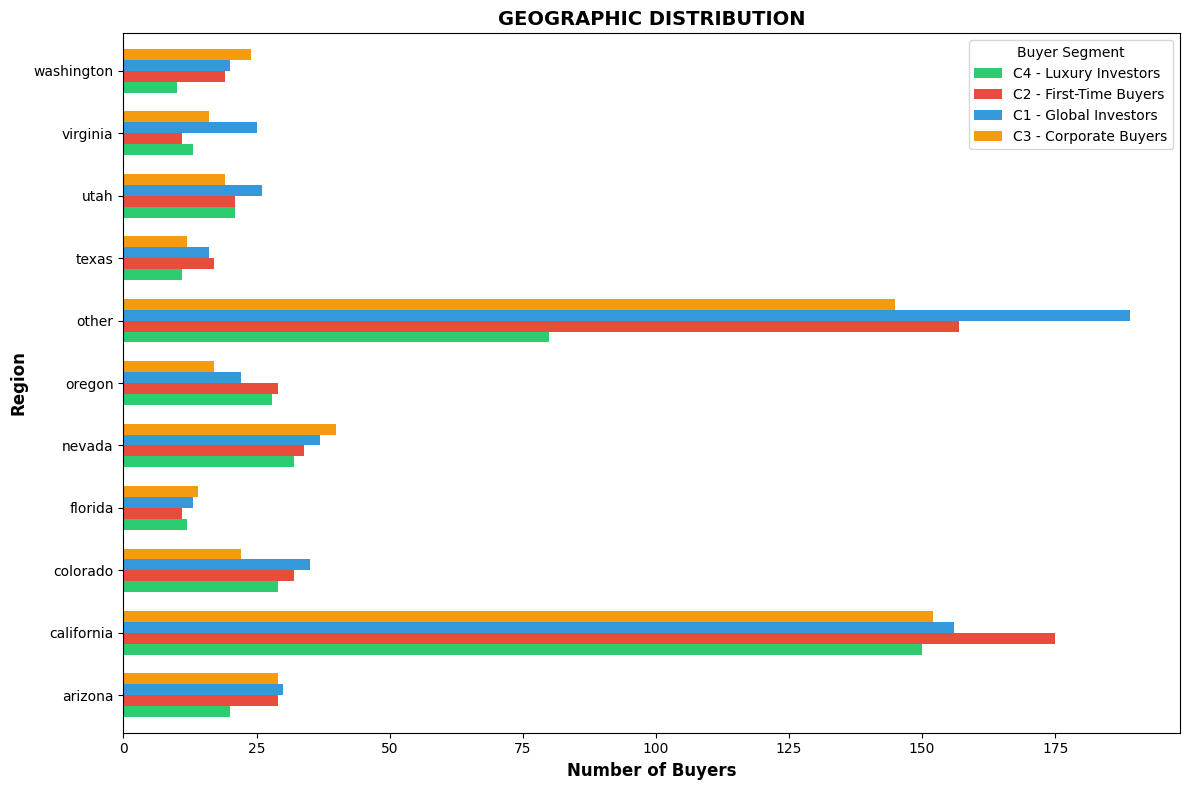

In [366]:
region_segment = pd.crosstab(final_df['region'], final_df['cluster'])
region_segment.columns = [segment_mapping[i] for i in range(4)]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
region_segment.plot(kind='barh', ax=ax, color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'], width=0.7)

plt.title('GEOGRAPHIC DISTRIBUTION', fontsize=14, fontweight='bold')
plt.xlabel('Number of Buyers', fontsize=12, fontweight='bold')
plt.ylabel('Region', fontsize=12, fontweight='bold')
plt.legend(title='Buyer Segment', fontsize=10)
plt.tight_layout()
plt.show()